# **BƯỚC 1: Kết nối Google Drive và Cấu hình**

In [40]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# CẤU HÌNH ĐƯỜNG DẪN (sửa ở đây nếu cần)
drive_data_path = '/content/drive/MyDrive/Project_CV/Student-engagement-dataset-clean'
model_path_h5 = '/content/drive/MyDrive/Project_CV/Student Engagement Model.h5'
svm_save_path = '/content/drive/MyDrive/Project_CV/svm_final_model.pkl'

print("Đã kết nối Drive thành công!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đã kết nối Drive thành công!


## **BƯỚC 2: Tự động chia dữ liệu (80% Train - 20% Test)**

In [41]:
import shutil
import random
from tqdm.notebook import tqdm

# Thư mục tạm trên Colab (Xử lý ở đây nhanh hơn trên Drive gấp 10 lần)
temp_dir = '/content/temp_data'

# Xóa nếu đã tồn tại để làm mới
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

print("Đang phân chia dữ liệu Train/Test...")

# Duyệt qua các thư mục mẹ (Engaged, Not Engaged...)
for root_folder in os.listdir(drive_data_path):
    root_path = os.path.join(drive_data_path, root_folder)

    if os.path.isdir(root_path):
        # Duyệt vào thư mục con (bored, confused, drowsy...)
        for class_name in os.listdir(root_path):
            class_path = os.path.join(root_path, class_name)

            if os.path.isdir(class_path):
                # Tạo thư mục đích
                os.makedirs(os.path.join(temp_dir, 'train', class_name), exist_ok=True)
                os.makedirs(os.path.join(temp_dir, 'test', class_name), exist_ok=True)

                # Lấy danh sách ảnh
                images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                random.shuffle(images) # Trộn ngẫu nhiên

                # Chia 80% Train - 20% Test
                split = int(len(images) * 0.8)
                train_imgs = images[:split]
                test_imgs = images[split:]

                # Copy ảnh
                for img in train_imgs:
                    shutil.copy(os.path.join(class_path, img), os.path.join(temp_dir, 'train', class_name, img))
                for img in test_imgs:
                    shutil.copy(os.path.join(class_path, img), os.path.join(temp_dir, 'test', class_name, img))

print(f"Đã chuẩn bị dữ liệu xong tại: {temp_dir}")

Đang phân chia dữ liệu Train/Test...
Đã chuẩn bị dữ liệu xong tại: /content/temp_data


# **BƯỚC 3: Load CNN (file h5) & Cắt bỏ Softmax**

In [42]:
from tensorflow.keras.models import load_model, Model
import numpy as np

# 1. Load model CNN
print("Đang load model .h5...")
cnn_model = load_model(model_path_h5)
print("Load thành công!")

# 2. BẮT BUỘC: GỌI MODEL 1 LẦN ĐỂ BUILD GRAPH
dummy_input = np.zeros((1, 256, 256, 3))
_ = cnn_model.predict(dummy_input)

print("Model đã được build!")

# 3. Kiểm tra các layer (OPTIONAL – để bạn hiểu)
print("\nDanh sách layer:")
for i, layer in enumerate(cnn_model.layers):
    print(i, layer.name)

# 4. Cắt bỏ Softmax – lấy Dense(512)
feature_extractor = Model(
    inputs=cnn_model.layers[0].input,   # KHÔNG dùng cnn_model.input
    outputs=cnn_model.layers[-2].output # Dense(512)
)

print(f"\nFeature Extractor tạo thành công!")
print(f"Output shape: {feature_extractor.output_shape}")

Đang load model .h5...


Load thành công!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Model đã được build!

Danh sách layer:
0 conv2d
1 max_pooling2d
2 conv2d_1
3 conv2d_2
4 max_pooling2d_1
5 conv2d_3
6 conv2d_4
7 max_pooling2d_2
8 conv2d_5
9 conv2d_6
10 flatten
11 dense
12 dense_1

Feature Extractor tạo thành công!
Output shape: (None, 512)


# **BƯỚC 4: Trích xuất đặc trưng (Feature Extraction)**

In [43]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

IMG_SIZE = (256, 256)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    directory=os.path.join(temp_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    directory=os.path.join(temp_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)

def extract_features(model, generator):
    print("Extracting features...")
    features = model.predict(generator, verbose=1)
    labels = generator.classes
    return features, labels

X_train, y_train = extract_features(feature_extractor, train_gen)
X_test, y_test = extract_features(feature_extractor, test_gen)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Found 1694 images belonging to 6 classes.
Found 426 images belonging to 6 classes.
Class mapping: {'Looking Away': 0, 'bored': 1, 'confused': 2, 'drowsy': 3, 'engaged': 4, 'frustrated': 5}
Extracting features...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step
Extracting features...
14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Train shape: (1694, 512)
Test shape : (426, 512)


# **BƯỚC 5: Huấn luyện SVM & Lưu Model**

In [44]:
from sklearn.svm import SVC
import joblib

print("Đang train SVM...")

# Khởi tạo và Train SVM
# kernel='rbf' là tốt nhất cho đặc trưng ảnh
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

print("Train SVM hoàn tất!")

# Lưu model SVM lại để dùng cho App/Demo
joblib.dump(svm_model, svm_save_path)
print(f"Đã lưu model SVM tại: {svm_save_path}")

Đang train SVM...
Train SVM hoàn tất!
Đã lưu model SVM tại: /content/drive/MyDrive/Project_CV/svm_final_model.pkl


# **BƯỚC 6: Đánh giá kết quả & Vẽ biểu đồ**

ĐỘ CHÍNH XÁC (Accuracy): 94.84%


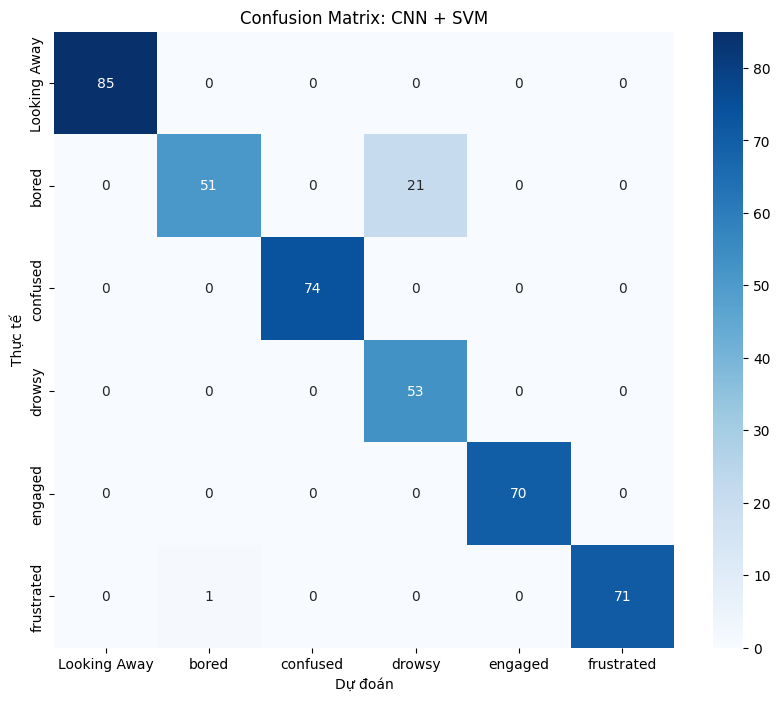


--- BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

Looking Away       1.00      1.00      1.00        85
       bored       0.98      0.71      0.82        72
    confused       1.00      1.00      1.00        74
      drowsy       0.72      1.00      0.83        53
     engaged       1.00      1.00      1.00        70
  frustrated       1.00      0.99      0.99        72

    accuracy                           0.95       426
   macro avg       0.95      0.95      0.94       426
weighted avg       0.96      0.95      0.95       426



In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dự đoán thử trên tập Test
y_pred = svm_model.predict(X_test)

# 2. Tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"ĐỘ CHÍNH XÁC (Accuracy): {acc * 100:.2f}%")

# 3. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
class_names = list(test_gen.class_indices.keys()) # Lấy tên các lớp (Bored, Engaged...)

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: CNN + SVM')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

# 4. Báo cáo chi tiết
print("\n--- BÁO CÁO CHI TIẾT ---")
print(classification_report(y_test, y_pred, target_names=class_names))